In [1]:
import numpy as np
import pandas as pd
import os
import librosa
import cv2
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from tensorflow.keras.preprocessing.image import img_to_array
import pyaudio
import wave
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns

# Video dataset loader
emotion_map = {'a': 0, 'f': 1, 'h': 2, 's': 3, 'n': 4}
video_emotion_labels = ['Angry', 'Fear', 'Happy', 'Sad', 'Neutral']
X, y = [], []

def extract_frames_from_video(video_path, label):
    cap = cv2.VideoCapture(video_path)
    frame_count = 0
    while True:
        ret, frame = cap.read()
        if not ret or frame_count >= 5:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        resized = cv2.resize(gray, (48, 48)) / 255.0
        X.append(resized.reshape(48, 48, 1))
        y.append(emotion_map[label])
        frame_count += 1
    cap.release()

for filename in os.listdir('Dataset1'):
    if filename.endswith('.mp4') and filename[0].lower() in emotion_map:
        extract_frames_from_video(os.path.join('Dataset1', filename), filename[0].lower())

X = np.array(X)
y = to_categorical(np.array(y), num_classes=5)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

video_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 1)),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

video_model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
history = video_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=64)
video_model.save('video_model.h5')

# Audio model
paths, labels = [], []
for dirname, _, filenames in os.walk('path'):
    for filename in filenames:
        if filename.endswith('.wav'):
            paths.append(os.path.join(dirname, filename))
            labels.append(filename.split('_')[-1].split('.')[0].lower())

audio_df = pd.DataFrame({'speech': paths, 'label': labels})

def extract_mfcc(filename):
    y, sr = librosa.load(filename, duration=3, offset=0.5)
    return librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T

X_mfcc = [extract_mfcc(f) for f in audio_df['speech']]
X_audio = np.array([x[:130] if x.shape[0] >= 130 else np.pad(x, ((0, 130 - x.shape[0]), (0, 0))) for x in X_mfcc])
X_audio = np.expand_dims(X_audio, axis=-1)

enc = OneHotEncoder()
y_audio = enc.fit_transform(audio_df[['label']]).toarray()

audio_model = Sequential([
    LSTM(256, input_shape=(130, 40)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(len(enc.categories_[0]), activation='softmax')
])

audio_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
audio_model.fit(X_audio, y_audio, validation_split=0.2, epochs=5, batch_size=64)
audio_model.save('audio_model.h5')


C:\Users\Alamin\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 306ms/step - accuracy: 0.1862 - loss: 1.6119 - val_accuracy: 0.1947 - val_loss: 1.5714
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.2695 - loss: 1.5529 - val_accuracy: 0.2212 - val_loss: 1.5498
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.2312 - loss: 1.5538 - val_accuracy: 0.2478 - val_loss: 1.5291
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.3333 - loss: 1.5110 - val_accuracy: 0.2566 - val_loss: 1.5100
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.3571 - loss: 1.4794 - val_accuracy: 0.3009 - val_loss: 1.4913
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.3601 - loss: 1.4407 - val_accuracy: 0.3363 - val_loss: 1.4712
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.4612 - loss: 1.4044 - val_accuracy: 0.3982 - val_loss: 1.4426
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.4374 - loss: 1.4115 - val_accuracy: 0.4425 - val_loss

Epoch 52/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8587 - loss: 0.4153 - val_accuracy: 0.9735 - val_loss: 0.3498
Epoch 53/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9226 - loss: 0.3516 - val_accuracy: 0.9646 - val_loss: 0.3648
Epoch 54/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8880 - loss: 0.3529 - val_accuracy: 0.9558 - val_loss: 0.3569
Epoch 55/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8994 - loss: 0.3504 - val_accuracy: 0.9823 - val_loss: 0.3169
Epoch 56/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8662 - loss: 0.3813 - val_accuracy: 0.9823 - val_loss: 0.3017
Epoch 57/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9223 - loss: 0.3170 - val_accuracy: 0.9823 - val_loss: 0.3169
Epoch 58/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8839 - loss: 0.3516 - val_accuracy: 0.9292 - val_loss: 0.3330
Epoch 59/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8669 - loss: 0.3764 - val_accuracy: 0.9823 - v

C:\Users\Alamin\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 481ms/step - accuracy: 0.3017 - loss: 1.5241 - val_accuracy: 0.3875 - val_loss: 1.5767
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 438ms/step - accuracy: 0.5699 - loss: 0.9251 - val_accuracy: 0.1650 - val_loss: 3.4487
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 432ms/step - accuracy: 0.7949 - loss: 0.5264 - val_accuracy: 0.3350 - val_loss: 3.3884
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 428ms/step - accuracy: 0.9413 - loss: 0.1639 - val_accuracy: 0.3575 - val_loss: 4.0883
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 431ms/step - accuracy: 0.9559 - loss: 0.1463 - val_accuracy: 0.4400 - val_loss: 3.5356


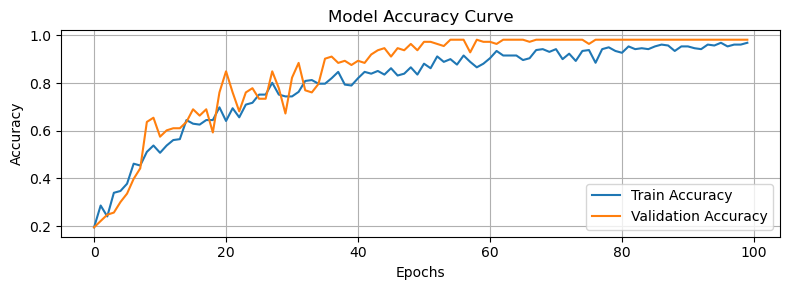

In [2]:
plt.figure(figsize=(8,3))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Prediction count: 113, True label count: 113


<Figure size 800x600 with 0 Axes>

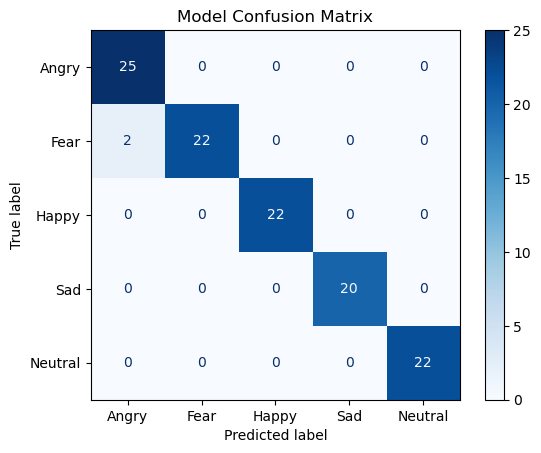

In [3]:
# Step 1: Predict on all test frames
y_pred_all = video_model.predict(X_test)

# Step 2: Cut predictions to match y_test length
y_pred_fixed = y_pred_all[:len(y_test)]

# Step 3: Get predicted and true labels
y_pred = np.argmax(y_pred_fixed, axis=1)
y_true = np.argmax(y_test, axis=1)

# Debug print
print(f"Prediction count: {len(y_pred)}, True label count: {len(y_true)}")

# Step 4: Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=video_emotion_labels)
disp.plot(cmap='Blues', values_format='d')
plt.title("Model Confusion Matrix")
plt.show()


In [4]:
from sklearn.metrics import classification_report, accuracy_score

print("Classification Report:\n", classification_report(y_true, y_pred, target_names=video_emotion_labels))
final_acc = accuracy_score(y_true, y_pred) * 100
print(f"\nFinal Accuracy on Test Set: {final_acc:.2f}%")


Classification Report:
               precision    recall  f1-score   support

       Angry       0.93      1.00      0.96        25
        Fear       1.00      0.92      0.96        24
       Happy       1.00      1.00      1.00        22
         Sad       1.00      1.00      1.00        20
     Neutral       1.00      1.00      1.00        22

    accuracy                           0.98       113
   macro avg       0.99      0.98      0.98       113
weighted avg       0.98      0.98      0.98       113


Final Accuracy on Test Set: 98.23%


In [5]:
audio_emotion_labels = enc.categories_[0]

def record_audio(filename, duration=3, rate=22050):
    CHUNK = 1024
    FORMAT = pyaudio.paInt16
    CHANNELS = 1
    p = pyaudio.PyAudio()
    stream = p.open(format=FORMAT, channels=CHANNELS, rate=rate, input=True, frames_per_buffer=CHUNK)
    frames = [stream.read(CHUNK) for _ in range(0, int(rate / CHUNK * duration))]
    stream.stop_stream()
    stream.close()
    p.terminate()

    wf = wave.open(filename, 'wb')
    wf.setnchannels(CHANNELS)
    wf.setsampwidth(p.get_sample_size(FORMAT))
    wf.setframerate(rate)
    wf.writeframes(b''.join(frames))
    wf.close()

cap = cv2.VideoCapture(0)
video_model = load_model('video_model.h5')
audio_model = load_model('audio_model.h5')

frame_count = 0
audio_interval = 150

while True:
    ret, frame = cap.read()
    if not ret:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml').detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_gray = cv2.resize(roi_gray, (48, 48)) / 255.0
        roi_gray = np.expand_dims(np.expand_dims(roi_gray, axis=0), axis=-1)
        video_prediction = video_model.predict(roi_gray, verbose=0)
        video_emotion = video_emotion_labels[np.argmax(video_prediction)]

        cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)
        cv2.putText(frame, video_emotion, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (36, 255, 12), 2)

    if frame_count % audio_interval == 0:
        record_audio('temp_audio.wav', duration=3)
        mfcc = extract_mfcc('temp_audio.wav')
        mfcc = mfcc[:130] if mfcc.shape[0] >= 130 else np.pad(mfcc, ((0, 130 - mfcc.shape[0]), (0, 0)))
        mfcc = np.expand_dims(mfcc, axis=(0, -1))
        audio_prediction = audio_model.predict(mfcc, verbose=0)
        audio_emotion = audio_emotion_labels[np.argmax(audio_prediction)]
        cv2.putText(frame, f'Audio: {audio_emotion}', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)

    frame_count += 1
    cv2.imshow('Emotion Detection', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
